## Libs

In [5]:

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.datasets import make_moons


from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")



Usando dispositivo: cuda


## 1. Classe do MLP

In [13]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size,
        num_classes,
        hidden_sizes,
        dropout_rate,
        learning_rate,
        momentum,
        activation_func,
        optimizer_class,
    ):
        super(MLP, self).__init__()
        layers = []
        in_layer = input_size
        self.learning_rate = learning_rate
        self.momentum = momentum
        
        # Construir camadas da rede
        for h_size in hidden_sizes:
            layers.append(nn.Linear(in_layer, h_size))
            layers.append(activation_func)
            layers.append(nn.Dropout(dropout_rate))
            in_layer = h_size

        # Camada de saída
        layers.append(nn.Linear(in_layer, num_classes))
        self.model = nn.Sequential(*layers)

        if optimizer_class == torch.optim.SGD:
            self.optimizer = optimizer_class(
                self.parameters(), lr=learning_rate, momentum=momentum
            )
        else:
            self.optimizer = optimizer_class(self.parameters(), lr=learning_rate)

    def forward(self, x):
        return self.model(x)


## Funções para Treinamento e Tunning

### Treino por época

In [7]:
def train_epoch(model, dataloader, loss_func, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        model.optimizer.zero_grad()
        outputs = model(X_batch)
        loss = loss_func(outputs, y_batch)
        loss.backward()
        model.optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(dataloader.dataset)


### Validação

In [8]:
def validate(model, dataloader, loss_func, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = loss_func(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            all_preds.append(outputs.cpu())
            all_labels.append(y_batch.cpu())
    avg_loss = total_loss / len(dataloader.dataset)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return avg_loss, all_preds, all_labels

### Tunning

In [ ]:


def create_objective(X, y, num_epochs, device):
    hyperparam_dict = {
        "hidden_sizes": [[64], [128], [64, 32], [128, 64]],
        "dropout_rate": (0.0, 0.5),
        "learning_rate": (1e-4, 1e-1),
        "momentum": (0.0, 0.9),
        "activation_func": [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
        "optimizer_class": [torch.optim.SGD, torch.optim.Adam],
    }
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    def objective(trial):
        # Hiperparâmetros a serem otimizados
        hidden_sizes = trial.suggest_categorical("hidden_sizes", hyperparam_dict["hidden_sizes"])
        learning_rate = trial.suggest_float("learning_rate", *hyperparam_dict["learning_rate"], log=True)
        momentum = trial.suggest_float("momentum", *hyperparam_dict["momentum"])
        dropout_rate = trial.suggest_float("dropout_rate", *hyperparam_dict["dropout_rate"])
        activation_func = trial.suggest_categorical("activation_func", hyperparam_dict["activation_func"])
        optimizer_class = trial.suggest_categorical("optimizer_class", hyperparam_dict["optimizer_class"])

        # Validação cruzada
        k = 5
        folds = KFold(n_splits=k, shuffle=True, random_state=42)
        val_losses = []
        val_accuracies = []

        for fold, (train_idx, val_idx) in enumerate(folds.split(X)):
            
            # Modelo e função de custo
            model = MLP(
                input_size=X.shape[1],
                num_classes=len(np.unique(y)),
                hidden_sizes=hidden_sizes,
                dropout_rate=dropout_rate,
                learning_rate=learning_rate,
                momentum=momentum,
                activation_func=activation_func,
                optimizer_class=optimizer_class,
            ).to(device)

            loss_func = nn.CrossEntropyLoss()

            # Dados
            train_subset = Subset(TensorDataset(
                    X_tensor[train_idx], 
                    y_tensor[train_idx]), 
                    range(len(train_idx))
                    )
            val_subset = Subset(TensorDataset(
                X_tensor[val_idx], 
                y_tensor[val_idx]), 
                range(len(val_idx))
                )
            train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
            val_loader = DataLoader(val_subset, batch_size=32)


            for epoch in range(num_epochs):
                train_epoch(model, train_loader, loss_func, device)

            # Validar no fold atual
            val_loss_fold, all_preds, all_labels = validate(model, val_loader, loss_func, device)
            accuracy = metrics.accuracy_score(all_labels.numpy(), all_preds.argmax(dim=1).numpy())

            print(f"Fold {fold+1}/{k} - Val Loss: {val_loss_fold:.4f} - Accuracy: {accuracy:.4f}")

            val_losses.append(val_loss_fold)
            val_accuracies.append(accuracy)

        # Retornar acuracia media
        return np.mean(val_accuracies)

    return objective

                

## Criacao de Dataset e Busca de Parametros

In [17]:


# test with make mooons first
X_train, y_train = make_moons(n_samples=1000, noise=0.3, random_state=42)
X_test, y_test = make_moons(n_samples=100, noise=0.2, random_state=43)


In [19]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='optuna')

study = optuna.create_study(direction="maximize")
objective_fun = create_objective(X_train, y_train, num_epochs=3, device=device)
study.optimize(objective_fun, n_trials=10)

[I 2026-04-06 16:52:56,607] A new study created in memory with name: no-name-bcddb0c7-4084-4b5f-b0fe-2e9d1df76f1d


Fold 1/5 - Val Loss: 0.3758 - Accuracy: 0.8000
Fold 2/5 - Val Loss: 0.3616 - Accuracy: 0.8650
Fold 3/5 - Val Loss: 0.3224 - Accuracy: 0.8550
Fold 4/5 - Val Loss: 0.3605 - Accuracy: 0.8400


[I 2026-04-06 16:52:57,500] Trial 0 finished with value: 0.8390000000000001 and parameters: {'hidden_sizes': [128], 'learning_rate': 0.004951119354577531, 'momentum': 0.024426421329152615, 'dropout_rate': 0.23722329284892157, 'activation_func': Sigmoid(), 'optimizer_class': <class 'torch.optim.adam.Adam'>}. Best is trial 0 with value: 0.8390000000000001.


Fold 5/5 - Val Loss: 0.3638 - Accuracy: 0.8350
Fold 1/5 - Val Loss: 0.6584 - Accuracy: 0.6750
Fold 2/5 - Val Loss: 0.6633 - Accuracy: 0.7850
Fold 3/5 - Val Loss: 0.6577 - Accuracy: 0.4950


[I 2026-04-06 16:52:58,248] Trial 1 finished with value: 0.664 and parameters: {'hidden_sizes': [128, 64], 'learning_rate': 0.0006195982115787937, 'momentum': 0.7070146743823194, 'dropout_rate': 0.2304810838512492, 'activation_func': ReLU(), 'optimizer_class': <class 'torch.optim.sgd.SGD'>}. Best is trial 0 with value: 0.8390000000000001.


...

Fold 4/5 - Val Loss: 0.5199 - Accuracy: 0.8300
Fold 5/5 - Val Loss: 0.4848 - Accuracy: 0.8000
Fold 1/5 - Val Loss: 0.3390 - Accuracy: 0.8400
Fold 2/5 - Val Loss: 0.3298 - Accuracy: 0.8800
Fold 3/5 - Val Loss: 0.3086 - Accuracy: 0.8750
Fold 4/5 - Val Loss: 0.3472 - Accuracy: 0.8400


[I 2026-04-06 16:53:03,955] Trial 8 finished with value: 0.859 and parameters: {'hidden_sizes': [64, 32], 'learning_rate': 0.004037723948158631, 'momentum': 0.30382085471738396, 'dropout_rate': 0.017185104704909915, 'activation_func': Tanh(), 'optimizer_class': <class 'torch.optim.adam.Adam'>}. Best is trial 8 with value: 0.859.


Fold 5/5 - Val Loss: 0.3276 - Accuracy: 0.8600
Fold 1/5 - Val Loss: 0.6891 - Accuracy: 0.7850
Fold 2/5 - Val Loss: 0.6914 - Accuracy: 0.5550
Fold 3/5 - Val Loss: 0.6909 - Accuracy: 0.4750


[I 2026-04-06 16:53:04,773] Trial 9 finished with value: 0.608 and parameters: {'hidden_sizes': [64, 32], 'learning_rate': 0.004880489836654694, 'momentum': 0.2532559405070813, 'dropout_rate': 0.4116665725803087, 'activation_func': Sigmoid(), 'optimizer_class': <class 'torch.optim.sgd.SGD'>}. Best is trial 8 with value: 0.859.


Fold 4/5 - Val Loss: 0.6919 - Accuracy: 0.4950
Fold 5/5 - Val Loss: 0.6883 - Accuracy: 0.7300


## Avaliação Final

In [20]:
best_model = MLP(
    input_size=X_train.shape[1],
    num_classes=len(np.unique(y_train)),
    hidden_sizes=study.best_params["hidden_sizes"],
    dropout_rate=study.best_params["dropout_rate"],
    learning_rate=study.best_params["learning_rate"],
    momentum=study.best_params["momentum"],
    activation_func=study.best_params["activation_func"],
    optimizer_class=study.best_params["optimizer_class"],
).to(device)

print("Best Hyperparameters:", study.best_params)

Best Hyperparameters: {'hidden_sizes': [64, 32], 'learning_rate': 0.004037723948158631, 'momentum': 0.30382085471738396, 'dropout_rate': 0.017185104704909915, 'activation_func': Tanh(), 'optimizer_class': <class 'torch.optim.adam.Adam'>}


In [21]:
# get metrics on test set
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
test_loader = DataLoader(test_dataset, batch_size=32)
test_loss, all_preds, all_labels = validate(best_model, test_loader, nn.CrossEntropyLoss(), device)
test_accuracy = metrics.accuracy_score(all_labels.numpy(), all_preds.argmax(dim=1).numpy())
print(f"Test Loss: {test_loss:.4f} - Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.7606 - Test Accuracy: 0.3100


## Fronteira de Decisão

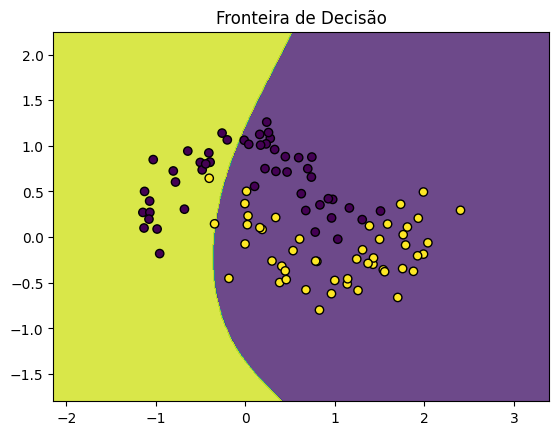

In [22]:
# Visualizar fronteira de decisão
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    with torch.no_grad():
        Z = model(grid).cpu().numpy()
    Z = Z.argmax(axis=1).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title("Fronteira de Decisão")
    plt.show()
    
plot_decision_boundary(best_model, X_test, y_test)
